1d. Write down and solve the master eqn and find an analytical expression for y(t) if P(X_0 = 1) = 1/3 and P(X_0 = 2)= 2/3. Using dsolve to do so. 

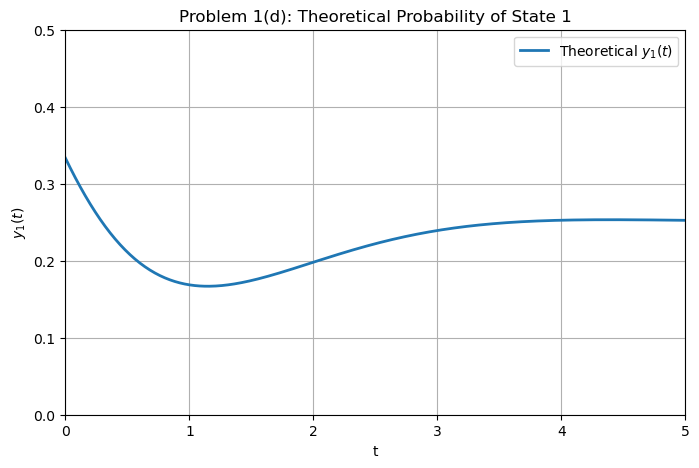

In [8]:
import math
import numpy as np 
import matplotlib.pyplot as plt
def y1_theory(t, k_max=40):
    t = np.asarray(t)
    result = np.zeros_like(t, dtype=float)

    for k in range(k_max + 1):
        result += (1/3) * np.exp(-t) * t**(4*k)     / math.factorial(4*k)
        result += (2/3) * np.exp(-t) * t**(4*k + 3) / math.factorial(4*k + 3)

    return result


# time grid
t_vals = np.linspace(0, 5, 500)

# plot theoretical solution
plt.figure(figsize=(8,5))
plt.plot(t_vals, y1_theory(t_vals), linewidth=2, label='Theoretical $y_1(t)$')

plt.xlim(0,5)
plt.ylim(0,0.5)
plt.xlabel("t")
plt.ylabel("$y_1(t)$")
plt.title("Problem 1(d): Theoretical Probability of State 1")
plt.legend()
plt.grid(True)
plt.show()

This is our theoretical curve. We will now create a series of simulations to test against it. I would expect the simulation curves to better map to this as the number of simulations increases. 

1e. Simulate N = 100, 1000, 10000, and 100000 independent Markov Chains with the initial condition of each chain randomly chosen to be i = 1 with probability 1/3 and i = 2 with probability 2/3. For each N, calculate and plot f(t), the fraction of chains that are in sa=tate 1 at time t, along with your theoretical solution from part d. Make the plot with horizontal range [0, 5] and a vertical range of [0, 1/2].

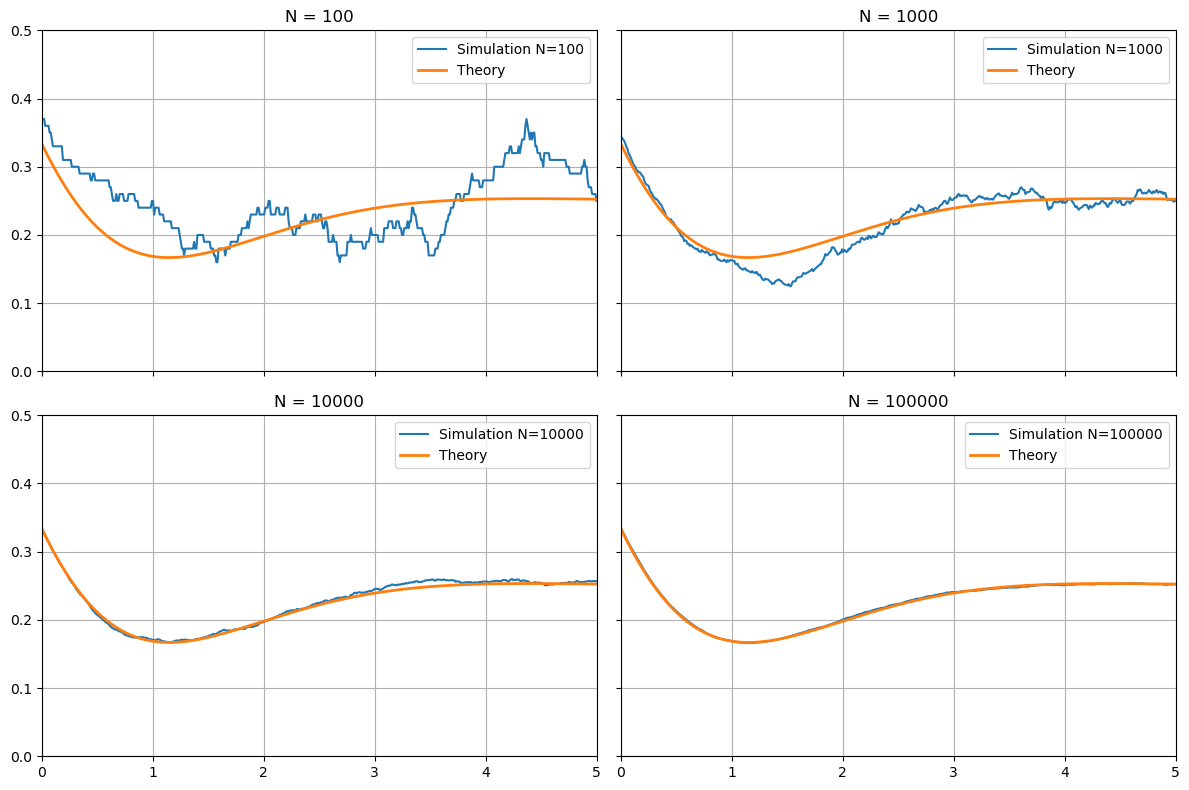

In [10]:
def y1_theory(t, k_max=40):
    t = np.asarray(t)
    result = np.zeros_like(t, dtype=float)

    for k in range(k_max + 1):
        result += (1/3) * np.exp(-t) * t**(4*k)     / math.factorial(4*k)
        result += (2/3) * np.exp(-t) * t**(4*k + 3) / math.factorial(4*k + 3)

    return result
def next_state(s):
    return (s + 1) % 4

def simulate_one_chain(t_grid):

    # initial state:
    # state 1 with prob 1/3
    # state 2 with prob 2/3
    state = np.random.choice([0,1], p=[1/3, 2/3])

    output = np.zeros(len(t_grid), dtype=int)

    current_time = 0
    next_jump = np.random.exponential(scale=1.0)

    for i, t in enumerate(t_grid):

        while next_jump <= t:
            state = next_state(state)
            current_time = next_jump
            next_jump = current_time + np.random.exponential(scale=1.0)

        output[i] = state

    return output

def simulate_one_chain(t_grid):

    # initial state:
    # state 1 with prob 1/3
    # state 2 with prob 2/3
    state = np.random.choice([0,1], p=[1/3, 2/3])

    output = np.zeros(len(t_grid), dtype=int)

    current_time = 0
    next_jump = np.random.exponential(scale=1.0)

    for i, t in enumerate(t_grid):

        while next_jump <= t:
            state = next_state(state)
            current_time = next_jump
            next_jump = current_time + np.random.exponential(scale=1.0)

        output[i] = state

    return output

def fraction_in_state_1(N, t_grid):

    count = np.zeros(len(t_grid))

    for _ in range(N):
        path = simulate_one_chain(t_grid)
        count += (path == 0)

    return count / N

t_grid = np.linspace(0,5,500)
N_values = [100, 1000, 10000, 100000]

fig, axes = plt.subplots(2,2, figsize=(12,8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, N in zip(axes, N_values):

    sim_vals = fraction_in_state_1(N, t_grid)
    theory_vals = y1_theory(t_grid)

    ax.plot(t_grid, sim_vals, label=f"Simulation N={N}")
    ax.plot(t_grid, theory_vals, linewidth=2, label="Theory")

    ax.set_xlim(0,5)
    ax.set_ylim(0,0.5)
    ax.set_title(f"N = {N}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Looking at this, we see as the number of independent markov chains increase going from 100, to 100,000 we see the simulation be a much better estimate of the theoretical curve. 

2c. For the particular case λN = λD = μN = μD = 1, X0 = N , solve the Master Equations explicitly using eigenvalues and eigenvectors and find the probability that the receptor is free at time t.


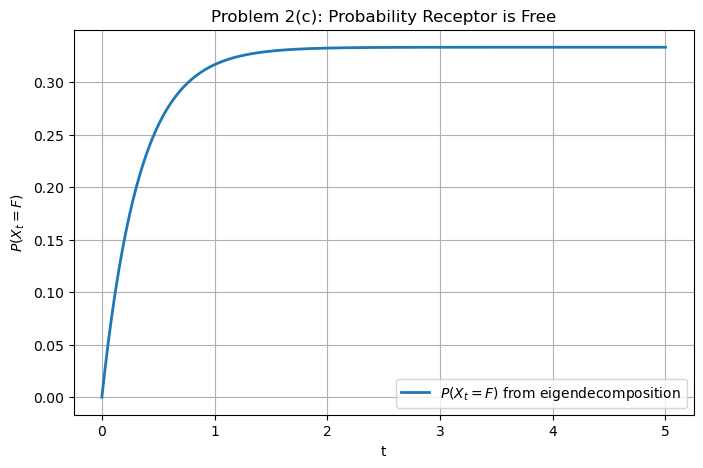

In [ ]:

import numpy as np
import matplotlib.pyplot as plt



Q = np.array([
    [-2,  1,  1],
    [ 1, -1,  0],
    [ 1,  0, -1]
], dtype=float)

# initial condition X0 = N
y0 = np.array([0, 1, 0], dtype=float)


# --------------------------------------------------
# eigendecomposition
# --------------------------------------------------
eigvals, eigvecs = np.linalg.eig(Q)

# solve for coefficients c in y0 = Vc
coeffs = np.linalg.solve(eigvecs, y0)


# y(t) from eigen-expansion

def y_t(t):
    exp_diag = np.diag(np.exp(eigvals * t))
    y = eigvecs @ exp_diag @ coeffs
    return np.real(y)


def p_free(t):
    return y_t(t)[0]   # first component = state F

# time grid and values
t_vals = np.linspace(0, 5, 500)
p_vals = np.array([p_free(t) for t in t_vals])

# plot
plt.figure(figsize=(8, 5))
plt.plot(t_vals, p_vals, linewidth=2, label=r"$P(X_t = F)$ from eigendecomposition")

plt.xlabel("t")
plt.ylabel(r"$P(X_t = F)$")
plt.title("Problem 2(c): Probability Receptor is Free")
plt.grid(True)
plt.legend()
plt.show()

Here we can clearly see as time increases so to does the probability that the state is free. 